In [1]:
%%capture
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install pennylane -q
!pip install torchinfo -q
!pip install graphviz -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 57.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 106.1 MB/s eta 0:00:0000:0100:01


In [3]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import timedelta

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from tqdm.auto import tqdm

import pennylane as qml
from torchinfo import summary as tinfo_summary
import graphviz

# precision
np.set_printoptions(precision=3)
torch.set_printoptions(precision=3)

In [4]:
IMG_SIZE   = 224
BATCH_SIZE = 6
EPOCHS     = 15
LR         = 0.00005
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
CSV_PATH = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/HAM10000_metadata.csv"
IMG_DIR  = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/Skin Cancer/Skin Cancer"

In [6]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [7]:
class SkinCancerDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df        = pd.read_csv(csv_file)
        self.img_dir   = img_dir
        self.transform = transform

        self.classes      = sorted(self.df['dx'].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.df['label']  = self.df['dx'].map(self.class_to_idx)

        self.image_paths, self.labels = [], []
        for _, row in self.df.iterrows():
            path = os.path.join(self.img_dir, row['image_id'] + ".jpg")
            if os.path.exists(path):
                self.image_paths.append(path)
                self.labels.append(row['label'])

        print(f"Total images: {len(self.image_paths)}")

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [8]:
full_dataset = SkinCancerDataset(CSV_PATH, IMG_DIR, transform)

CLASSES     = full_dataset.classes
num_classes = len(CLASSES)

train_size = int(0.70 * len(full_dataset))
val_size   = int(0.15 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Train: {train_size}  |  Val: {val_size}  |  Test: {test_size}")

Total images: 10015
Train: 7010  |  Val: 1502  |  Test: 1503


In [9]:
n_qubits = 2
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    # Data encoding
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    # Variational layers
    for l in range(n_layers):
        for i in range(n_qubits):
            qml.RX(weights[l, i], wires=i)
            qml.RZ(weights[l, i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[n_qubits - 1, 0])   # ring entanglement
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_layers, n_qubits))

    def forward(self, x):
        outputs = []
        for i in range(x.shape[0]):
            out = quantum_circuit(x[i], self.weights)
            outputs.append(torch.stack(out).float())
        return torch.stack(outputs)

In [10]:
class HybridMobileNet(nn.Module):
    """
    HybridMobileNet — updated architecture
    ───────────────────────────────────────
    Classical branch : original extra conv block (unchanged)
                       Conv2d 1x1 (1280->128) -> Conv2d 3x3 (128->64) -> AvgPool

    Quantum branch   : surgical change on the 2nd conv layer
                       Conv2d 1x1 (160->40) -> Dilated Conv2d 3x3 (40->8)
                         dilation=2, padding=1, activation=SiLU
                         (effective receptive field = 5x5)
                       -> AvgPool -> Linear (8->2) + tanh -> QuantumLayer
    """
    def __init__(self, num_classes):
        super().__init__()

        base = models.mobilenet_v2(weights="DEFAULT")
        self.features = base.features

        # Freeze first 50% of MobileNetV2 layers
        freeze_layers = len(self.features) // 2
        for i in range(freeze_layers):
            for p in self.features[i].parameters():
                p.requires_grad = False

        # ── Quantum branch ────────────────────────────────────────────────
        # Conv 1: standard 1x1 projection  160 -> 40
        self.q_conv1 = nn.Sequential(
            nn.Conv2d(160, 40, kernel_size=1, bias=False),
            nn.BatchNorm2d(40),
            nn.ReLU(inplace=True),
        )
        # Conv 2: DILATED 3x3  40 -> 8  |  dilation=2, padding=1  |  SiLU
        self.q_conv2 = nn.Sequential(
            nn.Conv2d(40, 8, kernel_size=3,
                      dilation=2, padding=1, bias=False),   # eff. field = 5x5
            nn.BatchNorm2d(8),
            nn.SiLU(inplace=True),                          # SiLU activation
        )
        self.q_pool  = nn.AdaptiveAvgPool2d((1, 1))
        self.q_fc    = nn.Linear(8, n_qubits)
        self.quantum = QuantumLayer()

        # ── Classical branch (original, unchanged) ────────────────────────
        self.extra = nn.Sequential(
            nn.Conv2d(1280, 128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # ── Classifier: 64 (classical) + 2 (quantum) ─────────────────────
        self.final_fc = nn.Linear(64 + n_qubits, num_classes)

    def forward(self, x):
        x = self.features[:17](x)          # shared backbone -> (B,160,14,14)

        # ── Quantum path ──────────────────────────────────────────────────
        q = self.q_conv1(x)                # (B, 40, 14, 14)
        q = self.q_conv2(q)                # (B,  8, 14, 14)  dilated+SiLU
        q = self.q_pool(q)                 # (B,  8,  1,  1)
        q = torch.flatten(q, 1)            # (B,  8)
        q = torch.tanh(self.q_fc(q))       # (B,  2)
        q = self.quantum(q)                # (B,  2)

        # ── Classical path ────────────────────────────────────────────────
        c = self.features[17:](x)          # (B, 1280, 7, 7)
        c = self.extra(c)                  # (B,   64, 7, 7)
        c = nn.functional.adaptive_avg_pool2d(c, (1, 1))
        c = torch.flatten(c, 1)            # (B,  64)

        out = torch.cat([c, q], dim=1)     # (B,  66)
        return self.final_fc(out)          # (B, num_classes)

In [11]:
model     = HybridMobileNet(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
print("Model instantiated successfully.")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 120MB/s]


Model instantiated successfully.


## 📊 Model Architecture — `torchinfo` Summary

In [12]:
print("\n" + "█"*72)
print("  HybridMobileNet  —  Dilated Quantum Branch + Original Classical Branch")
print("  Quantum conv2:  3×3 dilated (dil=2, pad=1) · SiLU  |  eff. field 5×5")
print("█"*72 + "\n")

model_stats = tinfo_summary(
    model,
    input_size=(1, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=24,
    row_settings=["var_names"],
    depth=4,
    verbose=1,
    device=device,
)

print("\n" + "="*60)
print(f"  {'Total parameters':<28} {model_stats.total_params:>12,}")
print(f"  {'Trainable parameters':<28} {model_stats.trainable_params:>12,}")
print(f"  {'Frozen parameters':<28} {(model_stats.total_params - model_stats.trainable_params):>12,}")
print("="*60)


████████████████████████████████████████████████████████████████████████
  HybridMobileNet  —  Dilated Quantum Branch + Original Classical Branch
  Quantum conv2:  3×3 dilated (dil=2, pad=1) · SiLU  |  eff. field 5×5
████████████████████████████████████████████████████████████████████████

Layer (type (var_name))                       Input Shape              Output Shape             Param #                  Trainable
HybridMobileNet (HybridMobileNet)             [1, 3, 224, 224]         [1, 7]                   --                       Partial
├─Sequential (features)                       --                       --                       (recursive)              Partial
│    └─Conv2dNormActivation (0)               [1, 3, 224, 224]         [1, 32, 112, 112]        --                       False
│    │    └─Conv2d (0)                        [1, 3, 224, 224]         [1, 32, 112, 112]        (864)                    False
│    │    └─BatchNorm2d (1)                   [1, 32, 112, 112]  

## 🗺️ Architecture Diagram (Graphviz — saved as PNG)

Diagram saved -> /kaggle/working/hybrid_mobilenet_dilated_q_arch.png


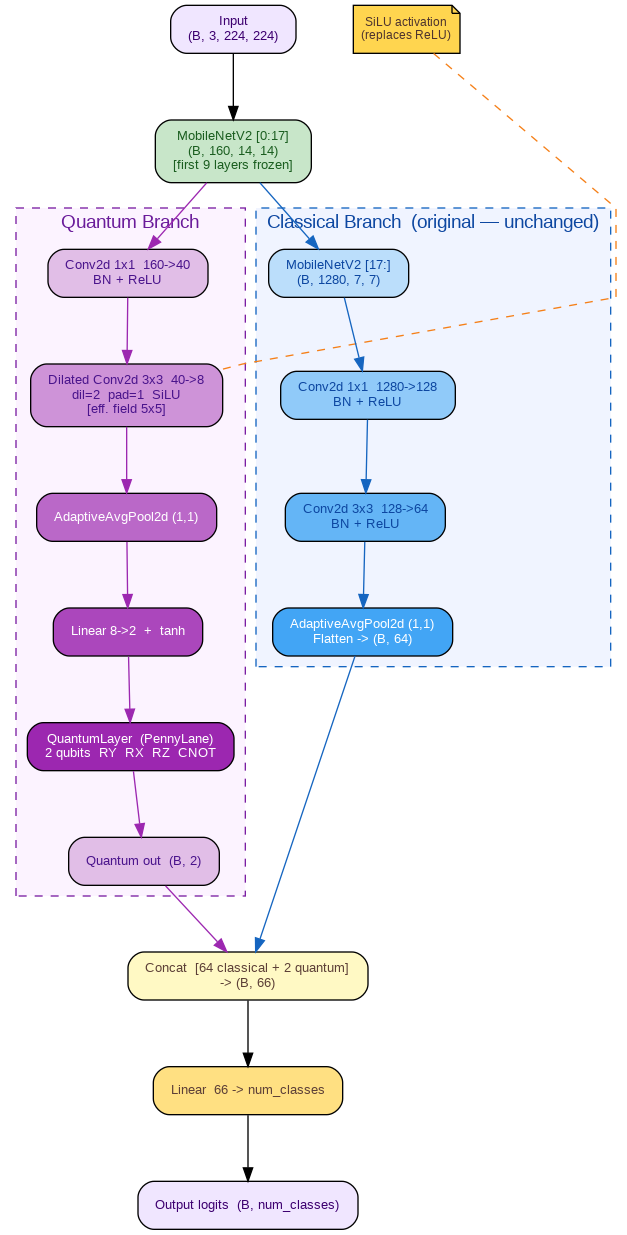

In [13]:
dot = graphviz.Digraph(
    name="HybridMobileNet_DilatedQ",
    comment="Skin Cancer Detection — Dilated Quantum Branch",
    format="png",
)
# splines="polyline" avoids the trapezoid-overflow crash that "ortho" triggers
dot.attr(rankdir="TB", splines="polyline", nodesep="0.6", ranksep="0.7",
         fontname="Helvetica", bgcolor="white")
dot.attr("node", shape="box", style="filled,rounded",
         fontname="Helvetica", fontsize="10", margin="0.18,0.10")

def N(name, label, color="#D6E4F7", fc="#1A2B4A"):
    dot.node(name, label, fillcolor=color, fontcolor=fc)

# Input
N("inp",     "Input\n(B, 3, 224, 224)",                        "#F0E6FF", "#3D0070")

# Shared backbone
N("feat016", "MobileNetV2 [0:17]\n(B, 160, 14, 14)\n[first 9 layers frozen]",
             "#C8E6C9", "#1B5E20")

dot.edge("inp", "feat016")

# ── Quantum branch ──────────────────────────────────────────────────────────
with dot.subgraph(name="cluster_quantum") as q:
    q.attr(label="Quantum Branch", style="dashed",
           color="#7B1FA2", fontcolor="#6A1B9A", bgcolor="#FCF3FF")
    layers_q = [
        ("qc1",  "Conv2d 1x1  160->40\nBN + ReLU",                       "#E1BEE7"),
        ("qc2",  "Dilated Conv2d 3x3  40->8\ndil=2  pad=1  SiLU\n[eff. field 5x5]",
                                                                           "#CE93D8"),
        ("qpool","AdaptiveAvgPool2d (1,1)",                                "#BA68C8"),
        ("qfc",  "Linear 8->2  +  tanh",                                  "#AB47BC"),
        ("qlyr", "QuantumLayer  (PennyLane)\n2 qubits  RY  RX  RZ  CNOT","#9C27B0"),
        ("qout", "Quantum out  (B, 2)",                                    "#E1BEE7"),
    ]
    for nid, lbl, col in layers_q:
        fc = "white" if col in ("#9C27B0","#AB47BC","#BA68C8") else "#4A148C"
        q.node(nid, lbl, fillcolor=col, fontcolor=fc,
               style="filled,rounded", shape="box",
               fontname="Helvetica", fontsize="10", margin="0.18,0.10")

# no inline label on edges — avoids ortho/xlabels warning
dot.edge("feat016", "qc1", color="#9C27B0")
for a, b in [("qc1","qc2"),("qc2","qpool"),("qpool","qfc"),("qfc","qlyr"),("qlyr","qout")]:
    dot.edge(a, b, color="#9C27B0")

# SiLU annotation as a standalone note node (constraint=false keeps it floating)
dot.node("silu_note", "SiLU activation\n(replaces ReLU)",
         shape="note", style="filled", fillcolor="#FFD54F", fontcolor="#4E342E",
         fontsize="9", fontname="Helvetica", margin="0.08,0.05")
dot.edge("silu_note", "qc2", style="dashed", arrowhead="none",
         color="#F57F17", constraint="false")

# ── Classical branch ────────────────────────────────────────────────────────
with dot.subgraph(name="cluster_classical") as c:
    c.attr(label="Classical Branch  (original — unchanged)",
           style="dashed", color="#1565C0", fontcolor="#0D47A1", bgcolor="#F0F4FF")
    layers_c = [
        ("feat17","MobileNetV2 [17:]\n(B, 1280, 7, 7)",          "#BBDEFB"),
        ("cc1",   "Conv2d 1x1  1280->128\nBN + ReLU",            "#90CAF9"),
        ("cc2",   "Conv2d 3x3  128->64\nBN + ReLU",              "#64B5F6"),
        ("cpool", "AdaptiveAvgPool2d (1,1)\nFlatten -> (B, 64)", "#42A5F5"),
    ]
    for nid, lbl, col in layers_c:
        fc = "white" if col == "#42A5F5" else "#0D47A1"
        c.node(nid, lbl, fillcolor=col, fontcolor=fc,
               style="filled,rounded", shape="box",
               fontname="Helvetica", fontsize="10", margin="0.18,0.10")

dot.edge("feat016", "feat17", color="#1565C0")
for a, b in [("feat17","cc1"),("cc1","cc2"),("cc2","cpool")]:
    dot.edge(a, b, color="#1565C0")

# ── Merge & classify ────────────────────────────────────────────────────────
N("cat", "Concat  [64 classical + 2 quantum]\n-> (B, 66)", "#FFF9C4", "#5D4037")
N("fc",  "Linear  66 -> num_classes",                        "#FFE082", "#5D4037")
N("out", "Output logits  (B, num_classes)",                  "#F0E6FF", "#3D0070")

dot.edge("qout",  "cat", color="#9C27B0")
dot.edge("cpool", "cat", color="#1565C0")
dot.edge("cat",   "fc")
dot.edge("fc",    "out")

out_path = "/kaggle/working/hybrid_mobilenet_dilated_q_arch"
dot.render(out_path, cleanup=True)
print(f"Diagram saved -> {out_path}.png")

from IPython.display import Image as IPImage
IPImage(filename=out_path + ".png", width=860)


## 🏋️ Training

In [14]:
def custom_metrics(y_pred, y_true, loss):
    y_pred = torch.argmax(y_pred, 1).cpu().numpy()
    y_true = y_true.cpu().numpy()
    return {
        "loss":     round(loss, 4),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
    }

In [15]:
train_hist = {"loss": [], "accuracy": []}
val_hist   = {"loss": [], "accuracy": []}

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ── train ──────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0
    preds, labels = [], []

    for x, y in tqdm(train_loader, desc="  train"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        preds.append(out.detach())
        labels.append(y)

    preds  = torch.cat(preds)
    labels = torch.cat(labels)
    tm = custom_metrics(preds, labels, train_loss / len(train_loader))
    train_hist["loss"].append(tm["loss"])
    train_hist["accuracy"].append(tm["accuracy"])
    print(f"  Train → loss: {tm['loss']:.4f}  acc: {tm['accuracy']:.4f}")

    # ── validate ───────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc="  val  "):
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()
            preds.append(out)
            labels.append(y)

    preds  = torch.cat(preds)
    labels = torch.cat(labels)
    vm = custom_metrics(preds, labels, val_loss / len(val_loader))
    val_hist["loss"].append(vm["loss"])
    val_hist["accuracy"].append(vm["accuracy"])
    print(f"  Val   → loss: {vm['loss']:.4f}  acc: {vm['accuracy']:.4f}")

elapsed = str(timedelta(seconds=int(time.time() - start_time)))
print(f"\nTotal training time: {elapsed}")


Epoch 1/15


  train:   0%|          | 0/1169 [00:00<?, ?it/s]

  Train → loss: 1.1489  acc: 0.6695


  val  :   0%|          | 0/251 [00:00<?, ?it/s]

  Val   → loss: 0.7005  acc: 0.7623

Epoch 2/15


...

  Val   → loss: 0.5843  acc: 0.8322

Epoch 15/15


  train:   0%|          | 0/1169 [00:00<?, ?it/s]

  Train → loss: 0.1481  acc: 0.9592


  val  :   0%|          | 0/251 [00:00<?, ?it/s]

  Val   → loss: 0.5961  acc: 0.8276

Total training time: 0:55:02


## 📈 Training Curves

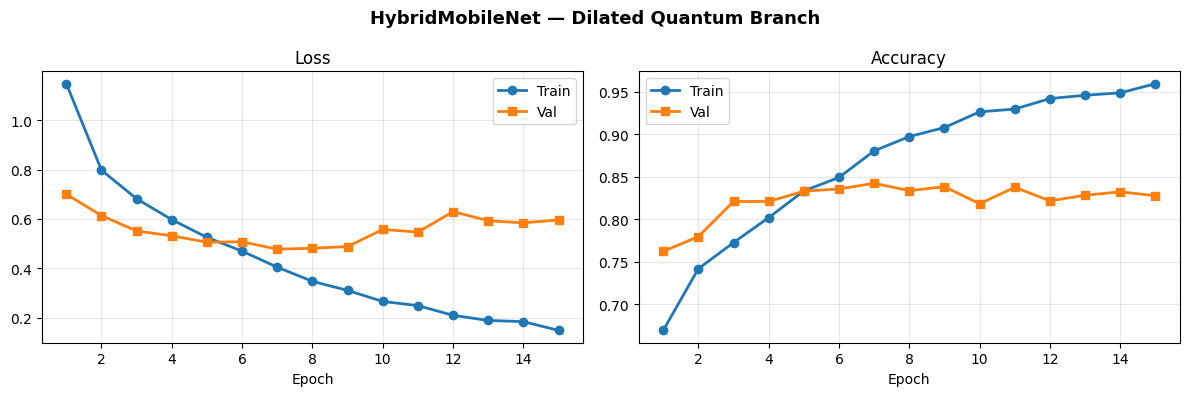

Saved → /kaggle/working/training_curves.png


In [16]:
epochs = range(1, len(train_hist["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("HybridMobileNet — Dilated Quantum Branch", fontsize=13, fontweight="bold")

for ax, metric in zip(axes, ["loss", "accuracy"]):
    ax.plot(epochs, train_hist[metric], marker="o", label="Train", linewidth=2)
    ax.plot(epochs, val_hist[metric],   marker="s", label="Val",   linewidth=2)
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /kaggle/working/training_curves.png")

## 🧪 Evaluation on Test Set

In [17]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="test"):
        x, y = x.to(device), y.to(device)
        out  = model(x)
        all_preds.append(out)
        all_labels.append(y)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
pred_cls   = torch.argmax(all_preds, dim=1)

report = classification_report(
    all_labels.cpu(), pred_cls.cpu(),
    target_names=CLASSES, digits=4,
)
print("\n" + "="*55)
print("CLASSIFICATION REPORT")
print("="*55)
print(report)

test:   0%|          | 0/251 [00:00<?, ?it/s]


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       akiec     0.6600    0.5893    0.6226        56
         bcc     0.7077    0.5823    0.6389        79
         bkl     0.8385    0.6899    0.7569       158
          df     0.8750    0.3500    0.5000        20
         mel     0.5987    0.5767    0.5875       163
          nv     0.8936    0.9494    0.9206      1008
        vasc     0.7273    0.8421    0.7805        19

    accuracy                         0.8397      1503
   macro avg     0.7572    0.6542    0.6867      1503
weighted avg     0.8350    0.8397    0.8340      1503



## 🔲 Confusion Matrix

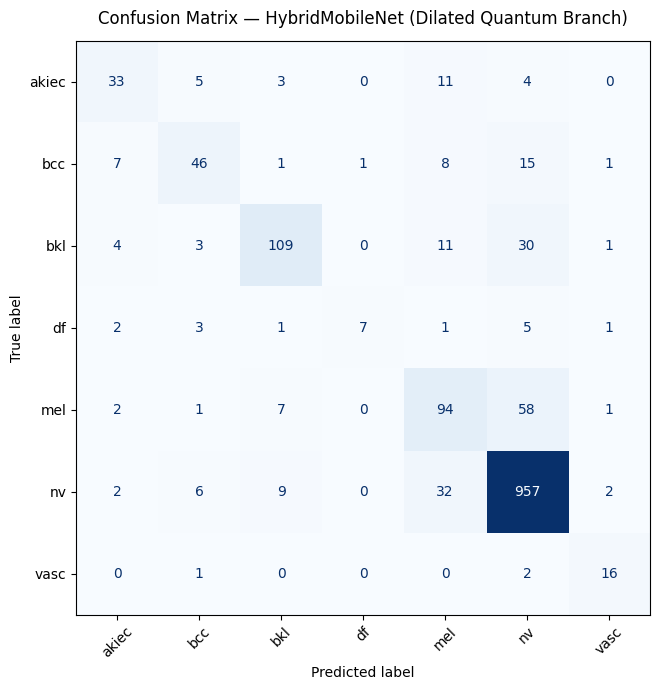

Saved → /kaggle/working/confusion_matrix.png


In [18]:
cm   = confusion_matrix(all_labels.cpu(), pred_cls.cpu())
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — HybridMobileNet (Dilated Quantum Branch)", pad=12)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /kaggle/working/confusion_matrix.png")

## 🔢 Parameter Summary

In [19]:
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print("\n" + "="*45)
print(f"  {'Total Parameters:':<26} {total_params:>10,}")
print(f"  {'Trainable Parameters:':<26} {trainable_params:>10,}")
print(f"  {'Frozen Parameters:':<26} {frozen_params:>10,}")
print("="*45)


  Total Parameters:           2,471,691
  Trainable Parameters:       2,340,875
  Frozen Parameters:            130,816
